In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("ecommerce_dataset.csv")
df.head()

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0


In [6]:
df.dtypes

order_id                 int64
product                    str
category                   str
price                  float64
quantity                 int64
payment_method             str
date                       str
total                  float64
Month                      str
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object

In [8]:
df = df.drop(columns=["Latitude","Longtitude"])
print("Columns drop ho gaye!")

Columns drop ho gaye!


In [9]:
df = df.rename(columns={'City Code': 'City', 'Order Priority Code': 'Order Priority'})
df.head(2)

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0


In [12]:
dublicate = df.duplicated().sum()
print("total dublicate rows",dublicate)

total dublicate rows 6


In [13]:
df = df.drop_duplicates()
print("Dublicate removed...")

Dublicate removed...


In [14]:
# now we check null value and missing
print(df.isnull().sum())

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64


In [16]:
# 'median()' darmiyani value nikalta hai. 'fillna' khali jagah ko us value se bhar deta hai.
median_total = df['total'].median()
df['total'] = df['total'].fillna(median_total)
print("Khali sales ki jagah median value dal di hai!")

Khali sales ki jagah median value dal di hai!


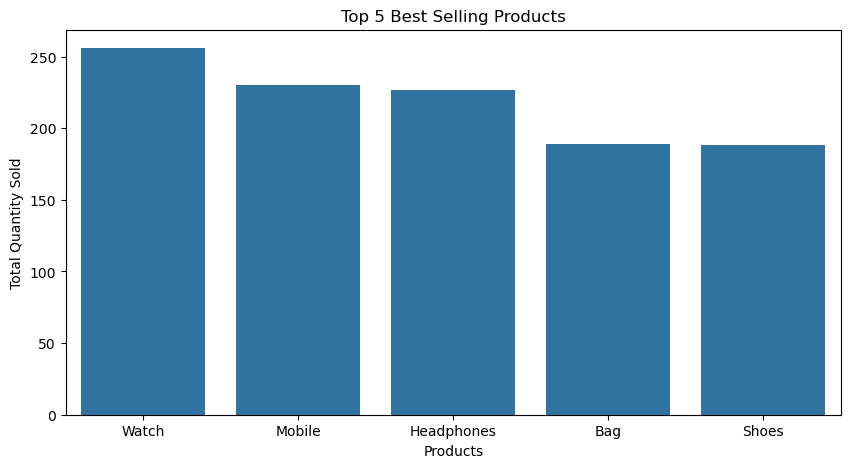

In [17]:
# Step 1: Har product ki quantity ko plus (sum) karo aur top 5 nikal lo
top_5_products = df.groupby('product')['quantity'].sum().nlargest(5)

# Step 2: Bar Chart banana (Seaborn se)
plt.figure(figsize=(10, 5)) # Graph ka size set kiya
sb.barplot(x=top_5_products.index, y=top_5_products.values)
plt.title("Top 5 Best Selling Products")
plt.xlabel("Products")
plt.ylabel("Total Quantity Sold")
plt.show()

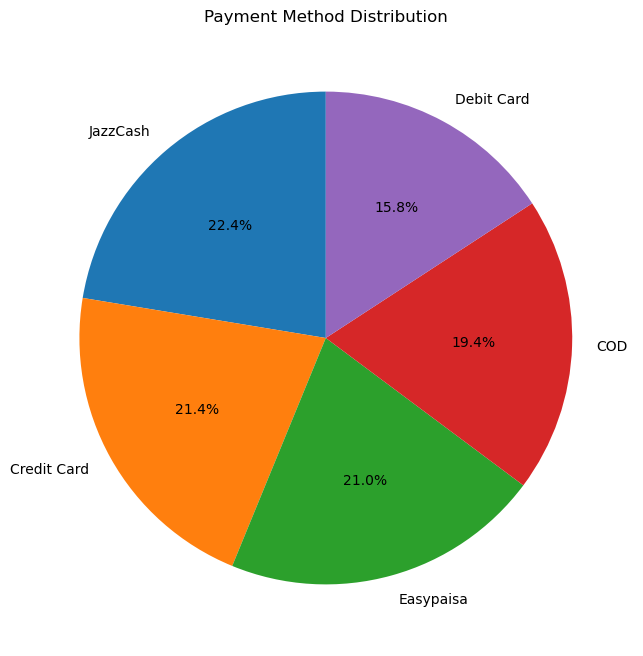

In [18]:
# 'value_counts()' har payment method ko ginta (count) hai
payment_counts = df['payment_method'].value_counts()

# Pie Chart banana (Matplotlib se)
plt.figure(figsize=(8, 8))
# autopct='%1.1f%%' percentage dikhane ke liye use hota hai
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Payment Method Distribution")
plt.show()

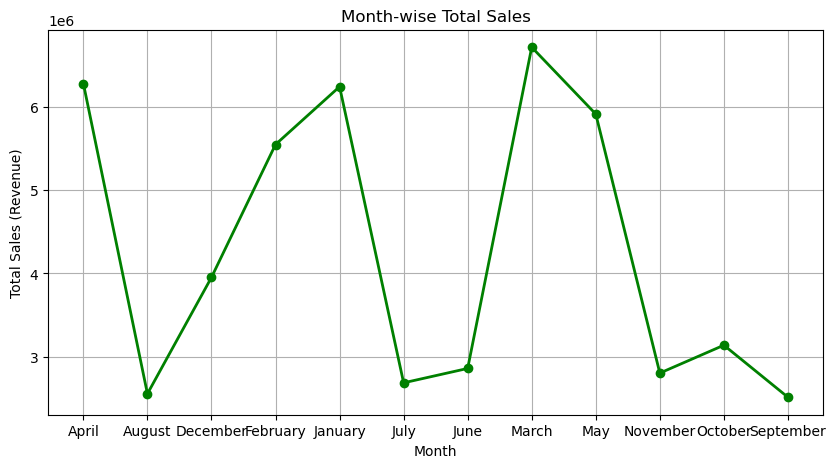

In [19]:
# Har mahine ki 'total' sales ko jama karo
monthly_sales = df.groupby('Month')['total'].sum()

# Line Chart banana (Matplotlib se)
plt.figure(figsize=(10, 5))
# marker='o' points par gol nishaan banata hai
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='green', linewidth=2)
plt.title("Month-wise Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales (Revenue)")
plt.grid(True) # Peeche line wala graph paper banata hai
plt.show()


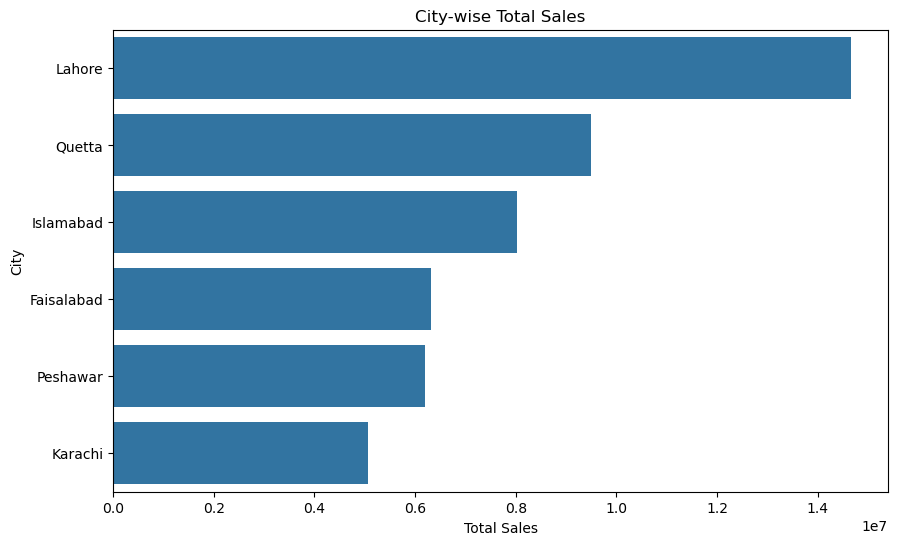

In [20]:
city_names = {1: 'Karachi', 2: 'Lahore', 3: 'Islamabad', 4: 'Faisalabad', 5: 'Quetta', 6: 'Peshawar'}
# 'replace' ne code ki jagah naam daal diye
df['City'] = df['City'].replace(city_names)

# Sales by city calculate ki
city_sales = df.groupby('City')['total'].sum().sort_values(ascending=False)

# b) Horizontal Bar Chart (Seaborn se)
plt.figure(figsize=(10, 6))
# orient='h' isko horizontal (leta hua) banata hai
sb.barplot(x=city_sales.values, y=city_sales.index, orient='h')
plt.title("City-wise Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.show()

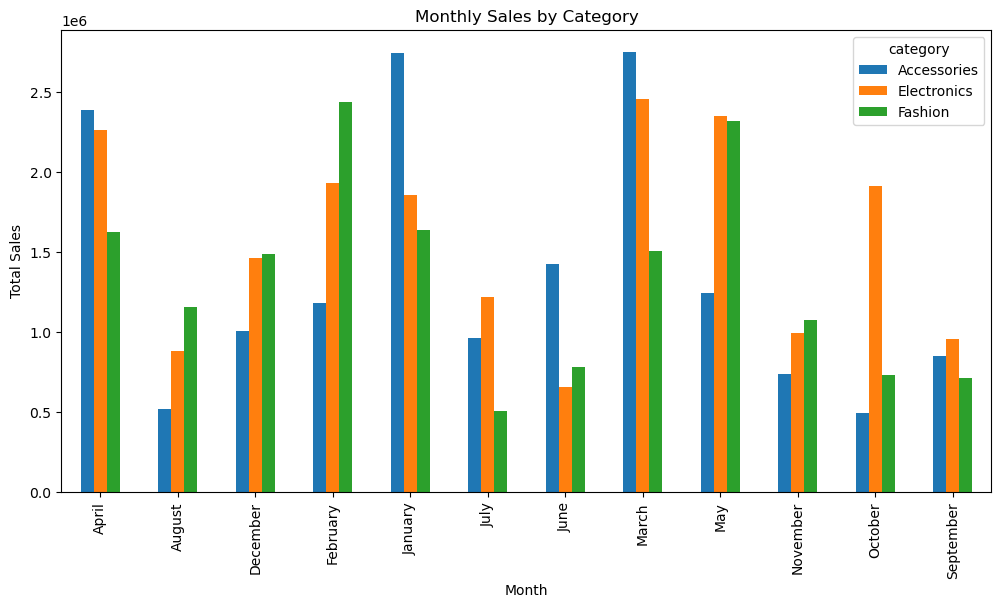

In [21]:
# 'pivot_table' Excel jaisa ek table banata hai jisme Mahine rows mein aur Category columns mein aati hain
category_monthly = df.pivot_table(index='Month', columns='category', values='total', aggfunc='sum')

# a) Side by side bar chart (Matplotlib se)
# kind='bar' likhne se khud hi side-by-side bars ban jate hain
category_monthly.plot(kind='bar', figsize=(12, 6))
plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()